# This notebook regroups all the code around graph formation/estimation (AKM estimator with MF at MANY DIMENSIONS)

Ce notebook reprend le même cheminement que le Notebook "clustering_AKM_MF_1D" avec cette fois des EF multi-dimensionnels 

## Packages and Import

In [236]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install bipartitepandas
#!pip install umap-learn

In [276]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

In [280]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_HNS as MF_HNS
import script.robustesse_simulation as robustesse_simulation
import script.density_ami_rmse_simulation as density_ami_rmse_simulation
import script.simulation_beta as simulation_beta
import script.simulation_regularization as simulation_regularization

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_HNS.get_estimations


# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_HNS)
importlib.reload(robustesse_simulation)
importlib.reload(density_ami_rmse_simulation)
importlib.reload(simulation_beta)
importlib.reload(simulation_regularization)

<module 'script.simulation_regularization' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/simulation_regularization.py'>

## Formation du graphe

Les lignes de codes suivantes génèrent un graphe biparti entre des patients et des docteurs dont les liens $Y_{ij}$ (vaut 1 s'il y a un lien entre i et j, 0 sinon) suivent un modèle AKM $\textcolor{red}{généralisé}$, c'est-à-dire la loi suivante:

$$P(Y_{ij} = 1 | X_{ij}) = (1 + e^{-T})^{-1}$$         
où    $T =  \textcolor{red}{<\alpha_{i} | \psi_{j} > }+ X_{ij}\beta$ 

NB: Ceci implique que les EF des docteurs et des patients soient de même taille.

Les EF ne sont désormais plus simplement des scalaires mais bien des vecteurs.

Les autres paramètres par défaut resteront inchangés par rapport à la version 1D

In [283]:
alpha_law_means = [[0,1], [1,1], [2,0]]
psi_law_means = [[0,1], [1,1], [2,0]]
identity_matrices = np.array([np.eye(2) for _ in range(3)])

In [284]:
#Exemple de foramtion de graphe avec des EF 2D

alpha_law_means = [[0,1], [1,1], [2,0]]
psi_law_means = [[0,1], [1,1], [2,0]]
identity_matrices = np.array([np.eye(2) for _ in range(3)])   # matrice de covariance de la gaussienne. (Ramené à 0_R^d par défaut)


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    dilatation_p = 1.5,
                    dilatation_d = 1.5,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 10.45%


## Etude préléminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Squared Error sur l'échantillon de test : 0.3410505844257657
Precision: 0.68
Recall: 0.59
F1-score: 0.64
ESTIMATION BETA: X p [0.14368232]; X d [0.01448273]; D_p [1.8086042]; D_d [2.059365]; distance [-17.101246]
ERROR ESTIMATION BETA: X p [-0.05631769]; X d [-0.18551728]; D_p [0.80860424]; D_d [1.059365]; distance [7.898754]


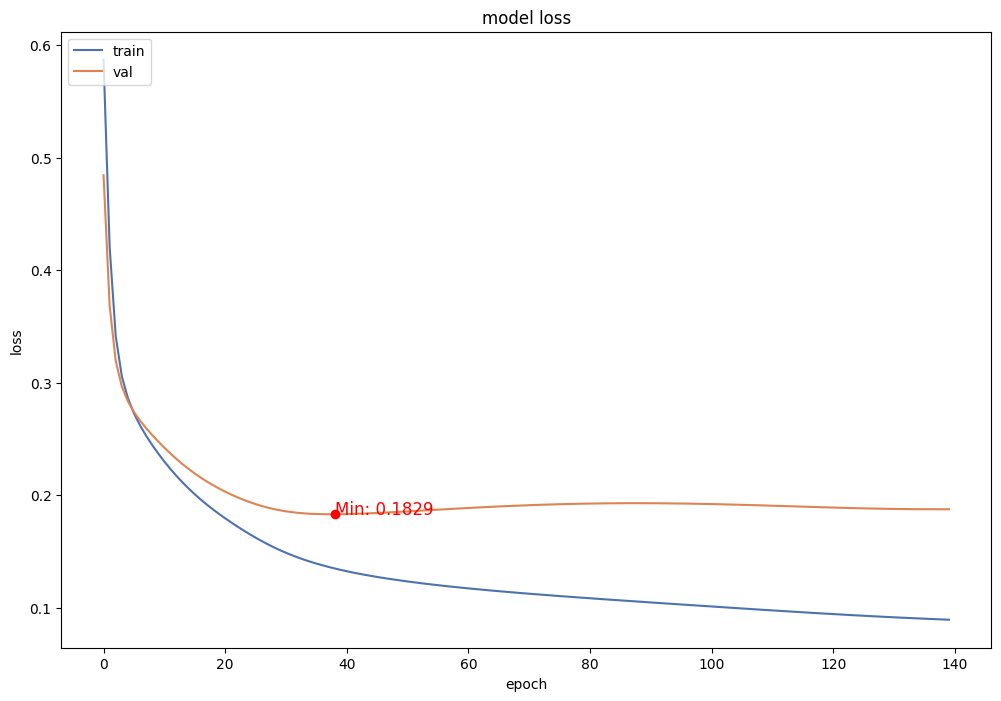

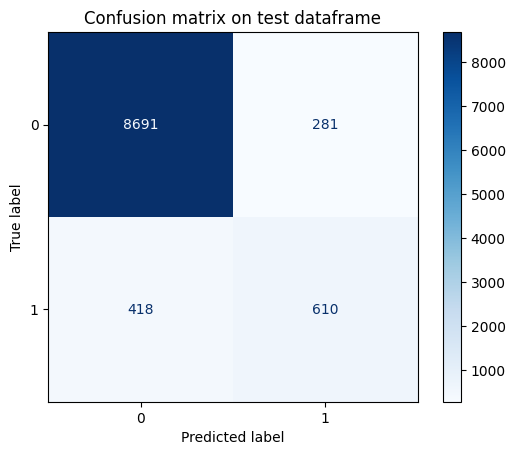

Temps d'exécution : 267 secondes


In [282]:
MF_HNS.prediction_score(graph_object, dim_embedding=2, nb_epochs=140, l_lambda = 0)

In [ ]:
MF_HNS.loss_vs_density(sim_beta_distance_array = [-25,-17, -13,-10, -8, -5,-3], nb_epochs=140)

density of the graph: 13.59%


## Etude de la qualité du clustering

### Visualisation

In [232]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -35,
                    dilatation_p = 2,
                    dilatation_d = 2,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 12.60%


In [233]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=200, show_print=0, dim_embedding=2)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

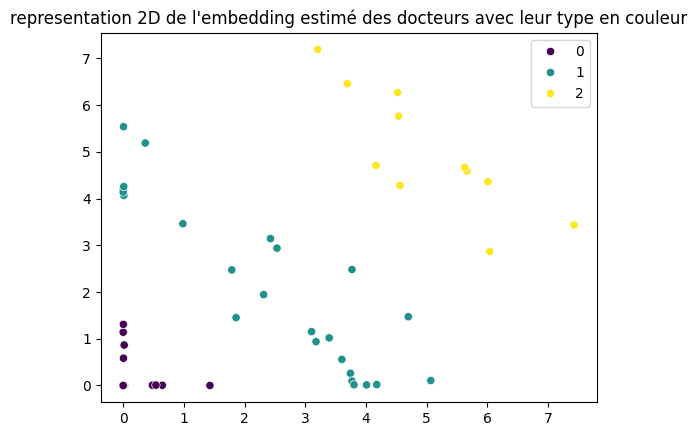

In [234]:
#Visualisation des EF docteur
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot( x= ef_doctor_hat[:,0], y=ef_doctor_hat[:,1], hue=graph_object.psi_class, palette='viridis')
plt.title("representation 2D de l'embedding estimé des docteurs avec leur type en couleur")
plt.show()

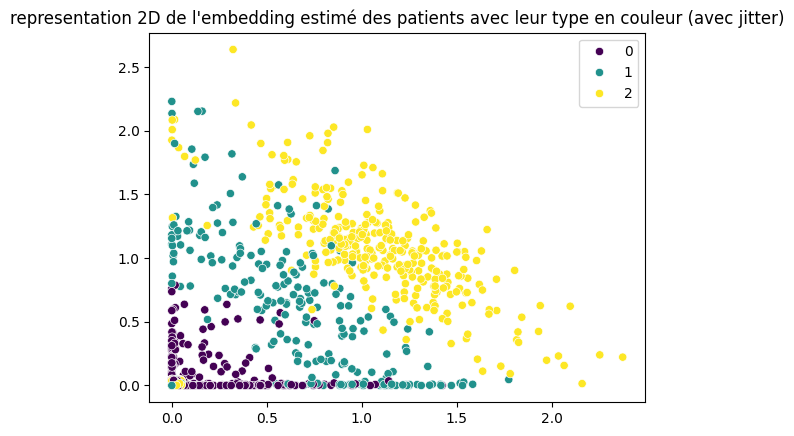

In [235]:
#Visualisation des EF patients
sns.set_palette("deep") 
# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_hat[:,0], y=  ef_patient_hat[:,1], hue=graph_object.alpha_class, palette='viridis')
plt.title("representation 2D de l'embedding estimé des patients avec leur type en couleur")
plt.show()

### Clustering, AMI et visualisation

In [250]:
# Initialiser le modèle KMeans avec 3 clusters
kmeans_d = KMeans(n_clusters=3, random_state=2)
# Ajuster le modèle sur les données
kmeans_d.fit(ef_doctor_hat)
# On retire les labels attribués
cluster_doctor_hat = kmeans_d.labels_

# Initialiser le modèle KMeans avec 3 clusters
kmeans_p = KMeans(n_clusters=3, random_state=3)
# Ajuster le modèle sur les données
kmeans_p.fit(ef_patient_hat)
# On retire les labels attribués
cluster_patient_hat = kmeans_p.labels_

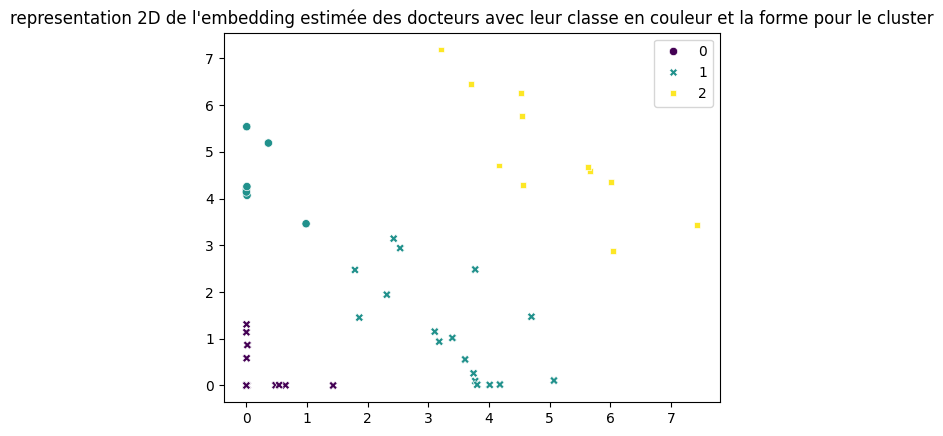

In [262]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_doctor_hat[:,0], y= ef_doctor_hat[:,1], hue=graph_object.psi_class, style=cluster_doctor_hat, palette='viridis')
plt.title("representation 2D de l'embedding estimée des docteurs avec leur classe en couleur et la forme pour le cluster")
plt.show()

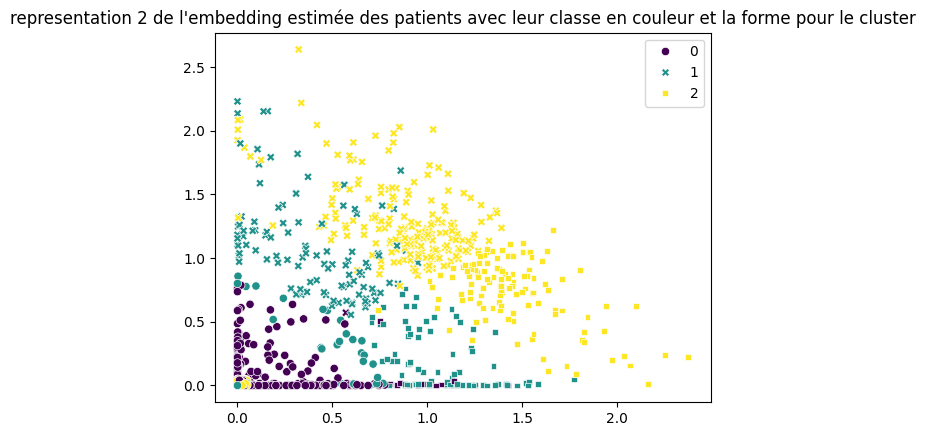

In [263]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_hat[:,0], y= ef_patient_hat[:,1], hue=graph_object.alpha_class, style=cluster_patient_hat, palette='viridis')
plt.title("representation 2 de l'embedding estimée des patients avec leur classe en couleur et la forme pour le cluster")
plt.show()

In [264]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.3775271189756744
AMI du clustering sur l'embedding estimé des patients: 0.23238537356918598
